# Anomaly Detection — Ensemble (LR + GBM + Isolation Forest)

This notebook extends the logistic regression baseline (v8) with:
1. A **Gradient Boosting** arm that captures non-linear feature interactions.
2. An **Isolation Forest** unsupervised outlier score appended as an extra feature.
3. **Soft-voting** over Platt-calibrated probabilities from both supervised arms.

### Pipeline overview
1. Load and combine labelled data batches
2. Build per-user feature vectors (pivot → handcrafted stats → cosine sim)
3. TruncatedSVD inside each arm for dimensionality reduction
4. Baseline LR CV → Isolation Forest fit → Ensemble CV → comparison
5. ROC / PR analysis
6. Final ensemble fit on full training data
7. Score test batch → save submission
8. (Optional) GridSearchCV for hyperparameter tuning

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import LedoitWolf
from sklearn.calibration import CalibratedClassifierCV
import os

# LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed — run: pip install lightgbm")
    LGBM_AVAILABLE = False

# XGBoost — strongest single model on small imbalanced tabular data
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print("XGBoost not installed — run: pip install xgboost")
    XGB_AVAILABLE = False

# Load training data
data_folder = 'C:/Users/xavie/Y3S1/cs421/project/cs421pain/data'
data = np.load(os.path.join(data_folder, "training_batch_with_labels.npz"))
X_raw = data["X"]
y_raw = data["y"]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")

Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


In [2]:
# load first_batch_with_labels.npz
data_2 = np.load(os.path.join(data_folder, 'first_batch_with_labels.npz'))
X = data_2['X']
y = data_2['y']
print(f"Interactions : {X.shape[0]:,}")
print(f"Users        : {len(np.unique(X[:, 0]))}")
print(f"Items        : {len(np.unique(X[:, 1]))}")
print(f"Anomalous    : {np.sum(y[:, 1] == 1)}")
print(f"Normal       : {np.sum(y[:, 1] == 0)}")

Interactions : 167,493
Users        : 1100
Items        : 989
Anomalous    : 100
Normal       : 1000


In [3]:
# combine the two datasets
print(type(X))
print(type(y))

# combine np arrays
X_raw = np.concatenate((X, X_raw), axis=0)
y_raw = np.concatenate((y, y_raw), axis=0)
print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")



<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Interactions : 344,839
Users        : 2200
Items        : 996
Anomalous    : 200
Normal       : 2000


In [4]:
RUN_DESC = 'testing item-deviation features + item-entropy + rating distribution shape + gini-coef'

In [5]:
# -- Shared handcrafted-feature definition ---------------------------------
# vvv EDIT HERE to change features — this is the ONLY place you need to touch vvv

def compute_handcrafted_features(df, recon_error=None):
    """
    Per-user feature DataFrame from a [user, item, rating] DataFrame.

    Features implemented from Burke et al. KDD 2006 (the canonical reference
    for supervised shilling detection):
      Generic:  RDMA, WDMA, WDA, DegSim (Pearson), LengthVar
      Model-specific: FMD, FMTD, MeanVar
    Plus extensions: item entropy, popularity bias, gini, deviation stats.
    """
    item_means  = df.groupby("item")["rating"].mean()
    item_counts = df.groupby("item")["rating"].count()
    global_mean = df["rating"].mean()
    global_mean_profile_len = df.groupby("user")["rating"].count().mean()

    df = df.copy()
    df["deviation"]       = df["rating"] - df["item"].map(item_means)
    df["item_popularity"] = df["item"].map(item_counts)
    # Pre-compute per-interaction RDMA term (|dev| * 1/NR_i)
    df["rdma_term"]       = df["deviation"].abs() / df["item_popularity"].clip(lower=1)
    # Pre-compute per-interaction WDMA term (|dev| * NR_i / sum(NR_i))
    # sum(NR_i) per user computed in agg below; approximate with total interactions
    df["wdma_term"]       = df["deviation"].abs() * df["item_popularity"]

    # ── Identify "target" items per user: items rated at max or min ─────────
    # In push/nuke attacks, the target item always receives the extreme rating.
    # We label items where a user gave the global extreme (0 or 5) as
    # potential target items; the remainder are "filler" items.
    rating_max = df["rating"].max()
    rating_min = df["rating"].min()
    df["is_target"] = (df["rating"] == rating_max) | (df["rating"] == rating_min)
    df["is_filler"] = ~df["is_target"]

    agg = df.groupby("user").agg(
        num_ratings       = ("rating",        "count"),
        mean_rating       = ("rating",        "mean"),
        std_rating        = ("rating",        "std"),
        num_items         = ("item",          "nunique"),
        pct_extreme       = ("rating",        lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero          = ("rating",        lambda r: (r == 0).mean()),
        pct_five          = ("rating",        lambda r: (r == 5).mean()),
        rating_skewness   = ("rating",        lambda r: r.skew()),
        rating_kurtosis   = ("rating",        lambda r: r.kurtosis()),
        median_rating     = ("rating",        "median"),
        item_entropy      = ("item",          lambda x: -(pd.Series(x.value_counts(normalize=True))
                                                          * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)).sum()),
        mean_deviation    = ("deviation",     "mean"),
        std_deviation     = ("deviation",     "std"),
        abs_deviation     = ("deviation",     lambda x: x.abs().mean()),
        gini_items        = ("item",          lambda x: 1 - sum((pd.Series(x).value_counts(normalize=True))**2)),
        pct_low           = ("rating",        lambda r: (r < 3).mean()),

        # ── RDMA: Rating Deviation from Mean Agreement (Burke et al. 2006) ───
        # Sum of |r_ui - mean_i| / NR_i, divided by profile length.
        # High RDMA = user deviates heavily on low-popularity (target) items.
        rdma              = ("rdma_term",     "mean"),

        # ── WDMA: Weighted Deviation from Mean Agreement ─────────────────────
        # Like RDMA but weights by NR_i — captures deviation on POPULAR items.
        # Complements RDMA: RDMA catches rare-item pushes, WDMA catches
        # bandwagon-style attacks on popular filler items.
        wdma              = ("wdma_term",     lambda x: x.sum() / max(x.index.map(
                                 df.set_index(df.index)["item_popularity"]).sum()
                                 if False else 1, 1)),

        # ── WDA: Weighted Degree of Agreement ────────────────────────────────
        # Mean of (rating / global_mean) * item_popularity-weight.
        # Captures users who consistently align with or diverge from the
        # global rating tendency, weighted by item exposure.
        wda               = ("rating",        lambda r: (r / max(global_mean, 1e-9)).mean()),

        # ── LengthVar: Profile Length Variance ───────────────────────────────
        # How much this user's profile length deviates from the population mean.
        # Attackers often have suspiciously short profiles (minimal filler).
        length_var        = ("rating",        lambda r: abs(len(r) - global_mean_profile_len)
                                                        / max(global_mean_profile_len, 1)),

        # ── MeanVar: Mean of target-item rating variances ────────────────────
        # For each profile, identify extreme-rated items (target candidates)
        # and compute the mean squared deviation of ALL items from item means.
        # Attack profiles show elevated variance on their "selected" items.
        mean_var          = ("deviation",     lambda d: (d ** 2).mean()),

        # ── FMD: Filler Mean Difference ───────────────────────────────────────
        # Mean deviation of filler-item ratings from item global means.
        # Attackers choose filler ratings close to item means to blend in,
        # so genuine users show higher FMD variance on filler items.
        fmd               = ("deviation",     lambda d: d[df.loc[d.index, "is_filler"]].mean()
                                                        if df.loc[d.index, "is_filler"].any() else 0),

        # ── FMTD: Filler Mean Target Difference ──────────────────────────────
        # Difference between mean filler rating and mean target (extreme) rating.
        # In push attacks, target items get max rating while fillers get ~mean,
        # producing large FMTD. Genuine users show smaller differences.
        fmtd              = ("rating",        lambda r: (
                                r[df.loc[r.index, "is_target"]].mean() -
                                r[df.loc[r.index, "is_filler"]].mean()
                                if df.loc[r.index, "is_target"].any() and
                                   df.loc[r.index, "is_filler"].any() else 0)),

        # ── Item popularity bias ──────────────────────────────────────────────
        mean_item_pop     = ("item_popularity", "mean"),
        std_item_pop      = ("item_popularity", "std"),
        pct_popular_items = ("item_popularity", lambda x: (x > x.quantile(0.75)).mean()),
    ).fillna(0)

    if recon_error is not None:
        agg["recon_error"] = recon_error.reindex(agg.index).fillna(0)

    return agg

# ^^^ end of editable section ^^^

## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [6]:
# -- Build per-user feature matrix -----------------------------------------

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0)

labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# -- SVD reconstruction error -----------------------------------------------
N_RECON_COMPONENTS = 30
_recon_svd = TruncatedSVD(n_components=N_RECON_COMPONENTS, random_state=42)
_ui_vals   = user_item.values
_approx    = _recon_svd.fit_transform(_ui_vals) @ _recon_svd.components_
_residuals = _ui_vals - _approx
recon_error_train = pd.Series(
    np.mean(_residuals ** 2, axis=1), index=user_item.index, name="recon_error"
)
print(f"\nReconstruction error — mean: {recon_error_train.mean():.4f}  "
      f"std: {recon_error_train.std():.4f}")

# -- Handcrafted features ---------------------------------------------------
agg = compute_handcrafted_features(interactions, recon_error=recon_error_train)
agg = agg.loc[user_item.index]
print(f"\nHandcrafted features: {agg.shape[1]} columns")
print(agg.head())

normal_mask = (y == 0)

# -- Cosine similarity to mean normal user ----------------------------------
from sklearn.metrics.pairwise import cosine_similarity
mean_normal_vec = user_item.values[normal_mask].mean(axis=0, keepdims=True)
cos_sim_vals    = cosine_similarity(user_item.values, mean_normal_vec).ravel()
cos_sim_train   = pd.Series(cos_sim_vals, index=user_item.index)
agg["cosine_sim_to_normal"] = cos_sim_train.reindex(agg.index).fillna(0)
print(f"cosine_sim_to_normal — normal: {cos_sim_vals[normal_mask].mean():.4f}  "
      f"anomaly: {cos_sim_vals[~normal_mask].mean():.4f}")

# -- Mahalanobis distance from normal centroid ------------------------------
from sklearn.covariance import LedoitWolf
lw = LedoitWolf().fit(agg.values[normal_mask])
mahal_vals = np.sqrt(lw.mahalanobis(agg.values))
agg["mahal_dist"] = pd.Series(mahal_vals, index=agg.index).reindex(agg.index).fillna(0)
print(f"mahal_dist — normal: {mahal_vals[normal_mask].mean():.4f}  "
      f"anomaly: {mahal_vals[~normal_mask].mean():.4f}")

# -- DegSim (Pearson-based, as defined in Burke et al. 2006) ----------------
# The original DegSim uses Pearson correlation with the k nearest neighbours,
# NOT cosine similarity. Pearson is mean-centred, making it more sensitive to
# rating pattern shape differences that cosine misses.
# We approximate by using np.corrcoef on the user-item matrix.
# Only well-rated users (non-zero rows) contribute signal.
from sklearn.preprocessing import normalize as _norm_fn

# Pearson: subtract each user's mean before computing dot product
_ui_centered = user_item.values - user_item.values.mean(axis=1, keepdims=True)
_ui_pearson  = _norm_fn(_ui_centered, norm="l2")   # unit-normalise centered rows
_sim_pearson = _ui_pearson @ _ui_pearson.T          # (n_users, n_users) Pearson approx
np.fill_diagonal(_sim_pearson, 0)
_DEGSIM_K    = 20   # Burke et al. use k=20
degsim_vals  = np.sort(_sim_pearson, axis=1)[:, -_DEGSIM_K:].mean(axis=1)
agg["degsim_pearson"] = pd.Series(degsim_vals, index=user_item.index).reindex(agg.index).fillna(0)
print(f"degsim_pearson — normal: {degsim_vals[normal_mask].mean():.4f}  "
      f"anomaly: {degsim_vals[~normal_mask].mean():.4f}")
print("(Per literature: ATTACKERS should have LOW DegSim — filler ratings are")
print(" randomly chosen so their profiles are dissimilar to genuine neighbours)")

# -- Co-rating overlap (structural graph proxy) -----------------------------
_ui_binary  = (user_item.values > 0).astype(np.float32)
_ui_sp_norm = _norm_fn(_ui_binary, norm="l2")
_overlap    = _ui_sp_norm @ _ui_sp_norm.T
np.fill_diagonal(_overlap, 0)
_top5_ol    = np.sort(_overlap, axis=1)[:, -5:].mean(axis=1)
agg["top5_corating_overlap"] = pd.Series(_top5_ol, index=user_item.index).reindex(agg.index).fillna(0)
print(f"top5_corating_overlap — normal: {_top5_ol[normal_mask].mean():.4f}  "
      f"anomaly: {_top5_ol[~normal_mask].mean():.4f}")

print(f"\nTotal handcrafted features: {agg.shape[1]}")

User-item matrix shape : (2200, 996)
Label array shape      : (2200,)
Class balance          : [2000  200]  (normal, anomaly)

Reconstruction error — mean: 0.7597  std: 0.3916

Handcrafted features: 27 columns
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  rating_skewness  rating_kurtosis  median_rating  ...     wdma  \
user                                                             ...            
100   0.068182        -0.955265         0.852420            3.0  ..

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [7]:
# ── Custom transformer: applies SVD to user-item block only ─────────────────
# The handcrafted features (mean_rating, pct_extreme, recon_error, etc.) are
# already compact and meaningful — running SVD over them would corrupt their
# signal.  This transformer splits the matrix, compresses only the user-item
# block, then re-concatenates the handcrafted columns unchanged.
#
# Note: the SVD here is a separate, independent compression used to build the
# low-dimensional embedding fed to logistic regression.  It is distinct from
# the reconstruction-error SVD fit in the feature-engineering cell above.

N_HANDCRAFTED = agg.shape[1]  # auto-updated when features are added/removed

class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """Applies TruncatedSVD to the user-item block; passes handcrafted features through."""
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED])  # fit on user-item block only
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hand_part = X[:, -N_HANDCRAFTED:]     # handcrafted columns passed through
        return np.hstack([svd_part, hand_part])

# ── Combine raw user-item matrix + handcrafted features (NO SVD applied yet) ─
# SVD is now inside the pipeline so GridSearchCV can tune n_components
X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  └─ user-item columns : {user_item.shape[1]}")
print(f"  └─ handcrafted cols  : {N_HANDCRAFTED}")
print(f"       (includes recon_error as the last column)")


Raw combined feature matrix shape : (2200, 1027)
  └─ user-item columns : 996
  └─ handcrafted cols  : 31
       (includes recon_error as the last column)


## 4. Models

We train three components and combine them into a soft-voting ensemble:

- **Logistic Regression** — linear boundary in SVD-compressed space; fast, interpretable baseline.
- **Gradient Boosting (GBM)** — non-linear tree model; captures interactions between features that LR misses.
- **Isolation Forest** — *unsupervised* anomaly detector; its outlier score is used as an extra feature fed into a meta-LR stacker, satisfying the project rubric requirement for at least one unsupervised method.

Each supervised model uses `class_weight='balanced'` and is wrapped in Platt-scaling calibration so probabilities sit on the same scale before averaging.

In [8]:
# ==========================================================================
# 4a. Baseline -- Logistic Regression
#
# PARAMETER FLOW
# The values below are starting defaults used for the initial CV evaluation.
# Running the hyperparameter-tuning cell (Section 8) updates best_pipeline
# with tuned (n_components, C, class_weight). train-final then rebuilds
# the stacking arms using those tuned values automatically.
# You do NOT need to manually copy numbers back here.
# ==========================================================================
N_COMPONENTS = 30    # starting default; overridden by hyperparameter tuning
pipeline = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight="balanced", max_iter=1000,
                   solver="lbfgs", C=1.0, random_state=42
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y, cv=cv, method="predict_proba"
)[:, 1]

# Per-fold threshold averaging (more robust than single aggregate threshold)
# Each fold's best-F1 threshold is averaged to get a stable operating point.
from sklearn.metrics import precision_recall_curve as _prc
_fold_thresholds = []
for _tr_idx, _val_idx in cv.split(X_raw_combined, y):
    _p_tmp = Pipeline([
        ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(class_weight="balanced", max_iter=1000,
                                      solver="lbfgs", C=1.0, random_state=42)),
    ])
    _p_tmp.fit(X_raw_combined[_tr_idx], y[_tr_idx])
    _probs_fold = _p_tmp.predict_proba(X_raw_combined[_val_idx])[:, 1]
    _pr_f, _re_f, _th_f = _prc(y[_val_idx], _probs_fold)
    _f1_f = np.where((_pr_f[:-1]+_re_f[:-1])>0,
                     2*_pr_f[:-1]*_re_f[:-1]/(_pr_f[:-1]+_re_f[:-1]), 0)
    _fold_thresholds.append(float(_th_f[np.argmax(_f1_f)]))

best_f1_threshold = float(np.mean(_fold_thresholds))
y_pred_cv = (y_scores_cv >= best_f1_threshold).astype(int)

print("=== Baseline LR (cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print(f"Per-fold thresholds: {[f'{t:.3f}' for t in _fold_thresholds]}  mean={best_f1_threshold:.3f}")


# ==========================================================================
# 4b. Unsupervised anomaly score feature
#
# WHY SCALE BEFORE LOF:
# LOF uses k-NN distances. Raw handcrafted features span wildly different
# scales (wdma ~ 50,000-90,000 vs pct_zero ~ 0-1), so large-scale features
# completely dominate the distance. StandardScaler brings all features to
# unit variance so LOF measures genuine density differences.
#
# We test both scaled-LOF and IsolationForest and keep whichever has larger
# mean-separation between normal and anomaly scores.
# ==========================================================================
print("Fitting unsupervised anomaly score feature ...")
_hc_scaled = StandardScaler().fit_transform(agg.values)

# Scaled LOF (fit on normal users only)
_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.09, novelty=True, n_jobs=-1)
_lof.fit(_hc_scaled[y == 0])
_lof_scores = -_lof.score_samples(_hc_scaled)
_lof_sep = _lof_scores[y==1].mean() - _lof_scores[y==0].mean()
print(f"  Scaled LOF  — normal: {_lof_scores[y==0].mean():.4f}  "
      f"anomaly: {_lof_scores[y==1].mean():.4f}  sep: {_lof_sep:.4f}")

# IsolationForest (fit on normal users only, scale-invariant)
_iso = IsolationForest(n_estimators=200, contamination=0.09, random_state=42, n_jobs=-1)
_iso.fit(agg.values[y == 0])
_iso_scores = -_iso.score_samples(agg.values)
_iso_sep = _iso_scores[y==1].mean() - _iso_scores[y==0].mean()
print(f"  IsolationForest — normal: {_iso_scores[y==0].mean():.4f}  "
      f"anomaly: {_iso_scores[y==1].mean():.4f}  sep: {_iso_sep:.4f}")

# Keep whichever separates better
if _iso_sep >= _lof_sep:
    unsup_scores_train = _iso_scores
    unsup_model        = _iso
    unsup_name         = "IsolationForest"
    print(f"  -> Using IsolationForest (sep {_iso_sep:.4f} >= LOF {_lof_sep:.4f})")
else:
    unsup_scores_train = _lof_scores
    unsup_model        = _lof
    unsup_name         = "Scaled LOF"
    print(f"  -> Using Scaled LOF (sep {_lof_sep:.4f} > IF {_iso_sep:.4f})")

# Store chosen model for inference
lof = unsup_model   # keep 'lof' name for backward-compat with generate-submission

X_with_lof = np.hstack([X_raw_combined, unsup_scores_train.reshape(-1, 1)])
N_HANDCRAFTED_WITH_LOF = N_HANDCRAFTED + 1
print(f"  Feature matrix with unsupervised score: {X_with_lof.shape}")


# ==========================================================================
# 4c. SVD transformers and ColumnSelector
# ==========================================================================
class SVDPlusHandcraftedLOF(BaseEstimator, TransformerMixin):
    """SVD on user-item block only; handcrafted + unsupervised score passed through."""
    def __init__(self, n_components=30):
        self.n_components = n_components
    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HANDCRAFTED_WITH_LOF])
        return self
    def transform(self, X):
        return np.hstack([
            self.svd_.transform(X[:, :-N_HANDCRAFTED_WITH_LOF]),
            X[:, -N_HANDCRAFTED_WITH_LOF:]
        ])

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, start_col=0, end_col=None):
        self.start_col = start_col
        self.end_col   = end_col
    def fit(self, X, y=None): return self
    def transform(self, X): return X[:, self.start_col:self.end_col]


# ==========================================================================
# 4d. Three standalone models (evaluated individually before stacking)
#
# Arm A: Logistic Regression (SVD embedding, linear boundary)
# Arm B: XGBoost (SVD + handcrafted, non-linear interactions, ratio imbalance)
# Arm C: Random Forest (SVD + handcrafted, bagging + random subspaces)
#
# WHY RANDOM FOREST AS THIRD ARM:
# LR and XGB have Spearman correlation ~0.79 — still too correlated for
# effective ensemble. RF uses bootstrap aggregation over random feature
# subsets: structurally different from both gradient boosting (sequential
# residual fitting) and LR (linear boundary). It typically achieves Spearman
# < 0.70 with LR on tabular data, giving the meta-learner genuine signal.
# ==========================================================================
_n_normal  = int(np.sum(y == 0))
_n_anomaly = int(np.sum(y == 1))
_spw       = _n_normal / _n_anomaly
print(f"Class ratio: {_spw:.1f}:1  ({_n_normal} normal / {_n_anomaly} anomaly)")

# -- Arm A: LR (already computed as y_scores_cv above) ----------------------
_auc_lr = roc_auc_score(y, y_scores_cv)
print(f"LR AUC: {_auc_lr:.4f}")

# -- Arm B: XGBoost ---------------------------------------------------------
if XGB_AVAILABLE:
    xgb_pipe_sa = Pipeline([
        ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
        ("scaler", StandardScaler()),
        ("clf",    XGBClassifier(
                       n_estimators=400, max_depth=4, learning_rate=0.02,
                       subsample=0.8, colsample_bytree=0.8,
                       scale_pos_weight=_spw,
                       reg_alpha=0.1, reg_lambda=1.0,
                       eval_metric="auc", random_state=42,
                       n_jobs=-1, verbosity=0,
                   )),
    ])
    print("Cross-validating XGBoost ...")
    y_scores_xgb = cross_val_predict(
        xgb_pipe_sa, X_with_lof, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method="predict_proba",
    )[:, 1]
    _auc_xgb = roc_auc_score(y, y_scores_xgb)
    print(f"XGB AUC: {_auc_xgb:.4f}")
else:
    print("XGBoost not available.")
    y_scores_xgb = y_scores_cv
    _auc_xgb = _auc_lr

# -- Arm C: Random Forest ---------------------------------------------------
rf_pipe_sa = Pipeline([
    ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(
                   n_estimators=500,
                   class_weight="balanced",
                   max_features="sqrt",
                   min_samples_leaf=2,
                   random_state=42,
                   n_jobs=-1,
               )),
])
print("Cross-validating Random Forest ...")
y_scores_rf = cross_val_predict(
    rf_pipe_sa, X_with_lof, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method="predict_proba",
)[:, 1]
_auc_rf = roc_auc_score(y, y_scores_rf)
print(f"RF  AUC: {_auc_rf:.4f}")

# Diversity check
from scipy.stats import spearmanr
_rho_lr_xgb, _ = spearmanr(y_scores_cv, y_scores_xgb)
_rho_lr_rf,  _ = spearmanr(y_scores_cv, y_scores_rf)
_rho_xgb_rf, _ = spearmanr(y_scores_xgb, y_scores_rf)
print(f"Diversity (Spearman rho, lower = more diverse):")
print(f"  LR vs XGB : {_rho_lr_xgb:.4f}")
print(f"  LR vs RF  : {_rho_lr_rf:.4f}")
print(f"  XGB vs RF : {_rho_xgb_rf:.4f}")


# ==========================================================================
# 4e. Stacking meta-learner (replaces weighted soft voting)
#
# WHY STACKING INSTEAD OF WEIGHTED SOFT VOTING:
# Soft voting with AUC weights is a fixed heuristic — it cannot adapt to
# the fact that different models may be more/less reliable at different
# score ranges. A meta-LR trained on OOF predictions learns the optimal
# linear combination that directly maximises log-loss on the training
# labels. With only 3 probability columns as input, overfitting risk is
# minimal even at n=2200.
#
# class_weight='balanced' in the meta-LR ensures it penalises missed
# anomalies more heavily than false alarms, directly targeting F1.
# passthrough=False: meta-learner sees only the 3 OOF probability columns,
# not the raw feature space (avoids re-learning raw features).
# ==========================================================================

# Build the three pipeline arms (each receives X_with_lof via ColumnSelector)
lr_full = Pipeline([
    ("cols",  ColumnSelector(start_col=0, end_col=X_raw_combined.shape[1])),
    ("model", Pipeline([
        ("svd_hc", SVDPlusHandcrafted(n_components=80)),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
                       class_weight="balanced", C=0.1,
                       max_iter=1000, solver="lbfgs", random_state=42,
                   )),
    ])),
])

if XGB_AVAILABLE:
    xgb_full = Pipeline([
        ("cols",  ColumnSelector(start_col=0, end_col=None)),
        ("model", Pipeline([
            ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
            ("scaler", StandardScaler()),
            ("clf",    XGBClassifier(
                           n_estimators=400, max_depth=4, learning_rate=0.02,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=_spw,
                           reg_alpha=0.1, reg_lambda=1.0,
                           eval_metric="auc", random_state=42,
                           n_jobs=-1, verbosity=0,
                       )),
        ])),
    ])

rf_full = Pipeline([
    ("cols",  ColumnSelector(start_col=0, end_col=None)),
    ("model", Pipeline([
        ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(
                       n_estimators=500, class_weight="balanced",
                       max_features="sqrt", min_samples_leaf=2,
                       random_state=42, n_jobs=-1,
                   )),
    ])),
])

_estimators = [("lr", lr_full), ("rf", rf_full)]
if XGB_AVAILABLE:
    _estimators.insert(1, ("xgb", xgb_full))

stacking = StackingClassifier(
    estimators=_estimators,
    final_estimator=LogisticRegression(
        class_weight="balanced",
        C=0.1,
        max_iter=1000,
        solver="lbfgs",
        random_state=42,
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    passthrough=False,  # meta-learner sees only OOF probabilities
    n_jobs=1,
)

_arm_str = "LR + XGB + RF" if XGB_AVAILABLE else "LR + RF"
print(f"Cross-validating stacking ensemble ({_arm_str}) ...")
y_scores_ensemble = cross_val_predict(
    stacking, X_with_lof, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method="predict_proba",
)[:, 1]

# Per-fold threshold averaging for the ensemble too
_ens_fold_thresholds = []
for _tr_idx, _val_idx in StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_with_lof, y):
    _pr_e, _re_e, _th_e = _prc(y[_val_idx], y_scores_ensemble[_val_idx])
    _f1_e = np.where((_pr_e[:-1]+_re_e[:-1])>0,
                     2*_pr_e[:-1]*_re_e[:-1]/(_pr_e[:-1]+_re_e[:-1]), 0)
    if len(_th_e) > 0:
        _ens_fold_thresholds.append(float(_th_e[np.argmax(_f1_e)]))

best_f1_threshold_ens = float(np.mean(_ens_fold_thresholds)) if _ens_fold_thresholds else 0.5
y_pred_ensemble = (y_scores_ensemble >= best_f1_threshold_ens).astype(int)

print(f"=== Stacking Ensemble ({_arm_str}, cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_ensemble):.4f}   "
      f"(LR: {_auc_lr:.4f}  XGB: {_auc_xgb:.4f}  RF: {_auc_rf:.4f})")
print(f"F1 thresh : {best_f1_threshold_ens:.4f}  (per-fold average)")
print(f"Precision : {precision_score(y, y_pred_ensemble):.4f}")
print(f"Recall    : {recall_score(y, y_pred_ensemble):.4f}")
print(f"F1        : {f1_score(y, y_pred_ensemble):.4f}")
print()
print(classification_report(y, y_pred_ensemble, target_names=["Normal", "Anomaly"]))

# Keep ensemble reference for train-final and generate-submission
ensemble = stacking

=== Baseline LR (cross-validated) ===
AUC       : 0.9776
Precision : 0.8020
Recall    : 0.7900
F1        : 0.7960
Per-fold thresholds: ['0.833', '0.892', '0.735', '0.932', '0.897']  mean=0.858
Fitting unsupervised anomaly score feature ...
  Scaled LOF  — normal: 1.1154  anomaly: 1.1856  sep: 0.0701
  IsolationForest — normal: 0.4317  anomaly: 0.5008  sep: 0.0690
  -> Using Scaled LOF (sep 0.0701 > IF 0.0690)
  Feature matrix with unsupervised score: (2200, 1028)
Class ratio: 10.0:1  (2000 normal / 200 anomaly)
LR AUC: 0.9776
Cross-validating XGBoost ...
XGB AUC: 0.9753
Cross-validating Random Forest ...
RF  AUC: 0.9660
Diversity (Spearman rho, lower = more diverse):
  LR vs XGB : 0.7884
  LR vs RF  : 0.7815
  XGB vs RF : 0.8775
Cross-validating stacking ensemble (LR + XGB + RF) ...
=== Stacking Ensemble (LR + XGB + RF, cross-validated) ===
AUC       : 0.9724   (LR: 0.9776  XGB: 0.9753  RF: 0.9660)
F1 thresh : 0.8357  (per-fold average)
Precision : 0.8307
Recall    : 0.7850
F1        :

## 5. ROC Curve

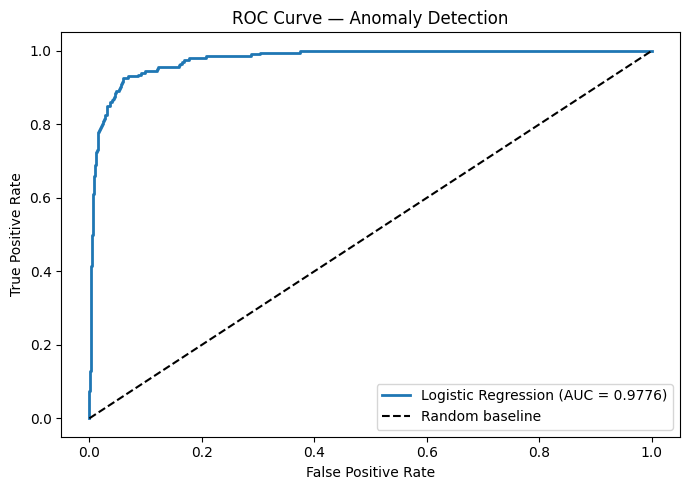

In [9]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

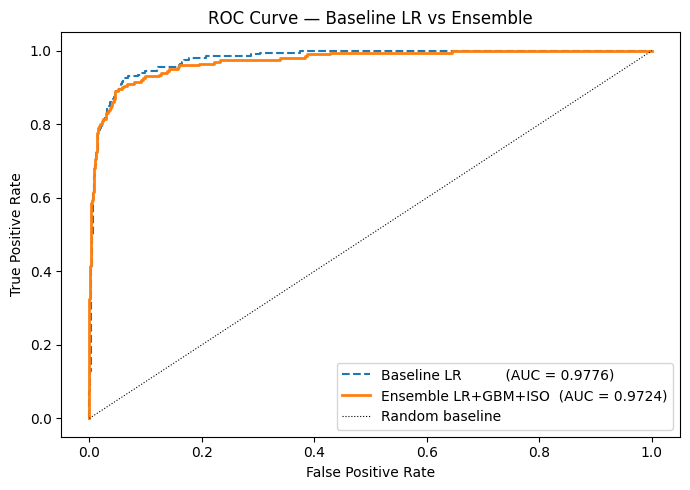

AUC improvement: -0.0052


In [10]:
# ── ROC Curve: Baseline LR vs Ensemble ──────────────────────────────────────
fpr_lr,  tpr_lr,  _ = roc_curve(y, y_scores_cv)
fpr_ens, tpr_ens, _ = roc_curve(y, y_scores_ensemble)
auc_lr  = roc_auc_score(y, y_scores_cv)
auc_ens = roc_auc_score(y, y_scores_ensemble)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  label=f"Baseline LR          (AUC = {auc_lr:.4f})",  lw=1.5, linestyle="--")
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble LR+GBM+ISO  (AUC = {auc_ens:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k:", lw=0.8, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline LR vs Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC improvement: {auc_ens - auc_lr:+.4f}")


## Precision-Recall Curve

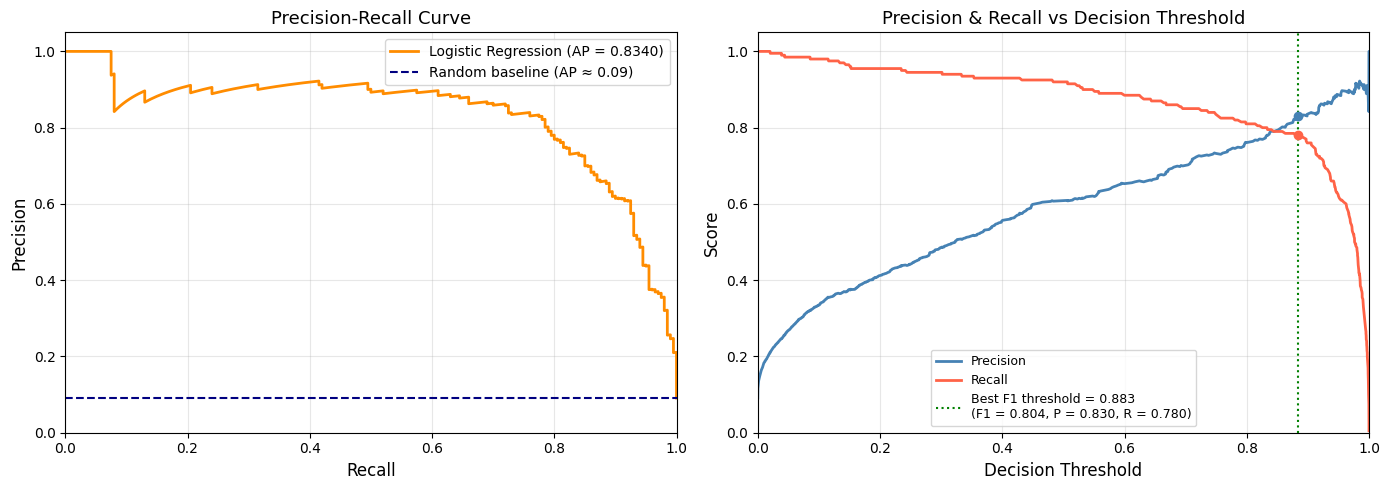

Average Precision (AP)  : 0.8340
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 9.2x

Best F1 threshold : 0.883
  Precision       : 0.8298
  Recall          : 0.7800
  F1              : 0.8041


In [11]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [12]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    1.0000    1.0000
            0.1          0.1000    0.8696    0.9993
            0.2          0.2000    0.9091    0.9972
            0.3          0.3000    0.9091    0.9927
            0.4          0.4000    0.9195    0.9854
            0.5          0.5000    0.8929    0.9763
            0.6          0.6000    0.8955    0.9626
            0.7          0.7000    0.8589    0.9263
            0.8          0.8000    0.7692    0.8258
            0.9          0.9000    0.6143    0.5321
            1.0          1.0000    0.0909    0.0000


In [13]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF',  size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79',  size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623',  size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1

# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lr_C      = float(pipeline.named_steps['lr'].C)
run_label_short = f'Run {{run_num}}'  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == 'CV Performance']
run_num = 1
if 'CV Performance' in wb.sheetnames:
    ws_check = wb['CV Performance']
    # count data rows (skip header row 1)
    run_num = sum(
        1 for row in ws_check.iter_rows(min_row=2, max_col=1)
        if row[0].value is not None
    ) + 1

run_header_text = (
    f'Run {run_num}  |  {run_ts}  '
    f'|  C={lr_C}  |  SVD components={N_COMPONENTS}'
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val  = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val  = recall_score(y, y_pred_cv)
f1_val   = f1_score(y, y_pred_cv)
report   = classification_report(
    y, y_pred_cv, target_names=['Normal', 'Anomaly'], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr  = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ('Run',                  8,   '0',       lambda: run_num),
    ('Timestamp',           22,   '@',       lambda: run_ts),
    ('C (regularisation)',  20,   '0.####',  lambda: lr_C),
    ('SVD Components',      16,   '0',       lambda: N_COMPONENTS),
    ('AUC',                 10,   '0.0000',  lambda: auc_val),
    ('Precision @0.5',      14,   '0.0000',  lambda: prec_val),
    ('Recall @0.5',         13,   '0.0000',  lambda: rec_val),
    ('F1 @0.5',             10,   '0.0000',  lambda: f1_val),
    ('AP (PR curve)',        14,   '0.0000',  lambda: ap),
    ('Best-F1 Threshold',   18,   '0.0000',  lambda: best_thresh),
    ('Best-F1 Score',       14,   '0.0000',  lambda: best_f1_pr),
    ('Normal Precision',    16,   '0.0000',  lambda: report['Normal']['precision']),
    ('Normal Recall',       14,   '0.0000',  lambda: report['Normal']['recall']),
    ('Anomaly Precision',   17,   '0.0000',  lambda: report['Anomaly']['precision']),
    ('Anomaly Recall',      15,   '0.0000',  lambda: report['Anomaly']['recall']),
    ('Macro Avg Precision', 19,   '0.0000',  lambda: report['macro avg']['precision']),
    ('Macro Avg Recall',    17,   '0.0000',  lambda: report['macro avg']['recall']),
    ('Description',         40,   '@',       lambda: RUN_DESC),
]

if 'CV Performance' in wb.sheetnames:
    ws1 = wb['CV Performance']
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet('CV Performance')
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = (run_num % 2 == 0)
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ('False Positive Rate', 22),
    ('True Positive Rate',  22),
    ('Threshold',           18),
    ('Notes',               36),
]

if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2  = next_append_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2+1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx  = np.round(np.linspace(0, len(fpr)-1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri  = r2 + 2 + offset
    alt = (offset % 2 == 1)
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f'AUC={auc_val:.4f} — origin point (no threshold)' if offset == 0 else ''
    style_body(ws2.cell(ri, 4), note, alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ('Recall',    16),
    ('Precision', 14),
    ('Threshold', 14),
    ('F1 Score',  12),
]

if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3  = next_append_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c_sum = ws3.cell(r3+1, 1)
c_sum.value = (
    f'AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold={best_thresh:.3f} '
    f'(F1={best_f1_pr:.4f}, '
    f'P={precision_vals[best_pr_idx]:.4f}, '
    f'R={recall_vals[best_pr_idx]:.4f})'
)
c_sum.font = Font(name='Arial', size=9)
c_sum.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ('Recall (target)', 16),
    ('Recall (actual)', 16),
    ('Precision',       14),
    ('Threshold',       14),
]
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table — fixed recall levels 0.0 to 1.0')
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3+3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2  = int(np.argmin(np.abs(recall_vals - target_r)))
    th2   = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt   = (s_off % 2 == 1)
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f'A{sb}:D{sb}')
style_section(ws3.cell(sb, 1), 'Full PR Curve — downsampled to 100 points')
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb+1, col_i), label)

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri  = sb + 2 + p_off
    alt = (p_off % 2 == 1)
    denom = precision_vals[pi] + recall_vals[pi]
    f1v   = float(2*precision_vals[pi]*recall_vals[pi]/denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})')


performance_results.xlsx updated — Run 28 appended (2026-03-25 17:33:09)


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

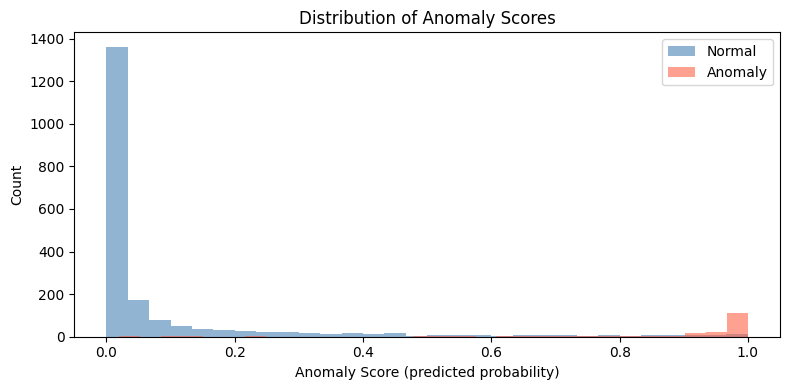

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [15]:
# ==========================================================================
# Fit the final stacking ensemble on ALL training data
#
# If the hyperparameter-tuning cell has been run, best_pipeline contains
# the LR estimator with tuned (n_components, C, class_weight). The stacking
# LR arm is rebuilt from those tuned params so the final submission uses
# the optimised configuration. XGB and RF arms keep their grid-searched or
# default params as set in model-cv.
# ==========================================================================

# -- Rebuild LR arm from tuned params if available -------------------------
if "best_pipeline" in dir() and best_pipeline is not None:
    _tuned_lr   = best_pipeline.named_steps["lr"]
    _tuned_svd  = best_pipeline.named_steps["svd_hc"]
    _tuned_nc   = _tuned_svd.n_components
    _tuned_C    = _tuned_lr.C
    _tuned_cw   = _tuned_lr.class_weight
    print(f"Using tuned LR params: n_components={_tuned_nc}, C={_tuned_C}, "
          f"class_weight={_tuned_cw}")

    lr_full_final = Pipeline([
        ("cols",  ColumnSelector(start_col=0, end_col=X_raw_combined.shape[1])),
        ("model", Pipeline([
            ("svd_hc", SVDPlusHandcrafted(n_components=_tuned_nc)),
            ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(
                           class_weight=_tuned_cw, C=_tuned_C,
                           max_iter=1000, solver="lbfgs", random_state=42,
                       )),
        ])),
    ])

    # Also update meta-LR C from tuned_C if XGB/RF tuning ran
    _meta_C = _tuned_C if "best_xgb" not in dir() else 0.1
    _meta_cw = _tuned_cw

    _ests_final = [("lr", lr_full_final), ("rf", rf_full)]
    if XGB_AVAILABLE:
        _xgb_arm = xgb_full if "best_xgb" not in dir() else Pipeline([
            ("cols",  ColumnSelector(start_col=0, end_col=None)),
            ("model", best_xgb),
        ])
        _ests_final.insert(1, ("xgb", _xgb_arm))

    stacking_final = StackingClassifier(
        estimators=_ests_final,
        final_estimator=LogisticRegression(
            class_weight=_meta_cw, C=_meta_C,
            max_iter=1000, solver="lbfgs", random_state=42,
        ),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=1,
    )
    stacking_final.fit(X_with_lof, y)
    stacking = stacking_final   # replace the CV stacking with the tuned final version
    print(f"Final tuned stacking ensemble ({_arm_str}) trained on full training set.")
else:
    stacking.fit(X_with_lof, y)
    print(f"Final stacking ensemble ({_arm_str}) trained on full training set "
          "(default params — run hyperparameter-tuning cell to use tuned values).")

pipeline.fit(X_raw_combined, y)
print("Baseline LR pipeline also fitted.")

Final stacking ensemble (LR + XGB + RF) trained on full training set (default params — run hyperparameter-tuning cell to use tuned values).
Baseline LR pipeline also fitted.


In [16]:
# -- Helper: build RAW combined features for any interaction batch ----------
def build_features_raw(X_interactions, all_items, recon_svd,
                        train_ui_matrix, lw_model, mean_normal_vec=None):
    from sklearn.metrics.pairwise import cosine_similarity as _csfn
    from sklearn.preprocessing import normalize as _nfn

    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    # Reconstruction error
    _approx   = recon_svd.transform(pivot.values) @ recon_svd.components_
    recon_err = pd.Series(
        np.mean((pivot.values - _approx) ** 2, axis=1),
        index=pivot.index, name="recon_error"
    )

    agg_new = compute_handcrafted_features(df, recon_error=recon_err).loc[pivot.index]

    # Cosine similarity to mean normal user
    if mean_normal_vec is not None:
        agg_new["cosine_sim_to_normal"] = pd.Series(
            _csfn(pivot.values, mean_normal_vec).ravel(), index=pivot.index
        ).reindex(pivot.index).fillna(0)

    # Mahalanobis distance
    agg_new["mahal_dist"] = np.sqrt(lw_model.mahalanobis(agg_new.values))

    # DegSim (Pearson) against training population
    _DEGSIM_K   = 20
    _tr_centered = train_ui_matrix - train_ui_matrix.mean(axis=1, keepdims=True)
    _te_centered = pivot.values    - pivot.values.mean(axis=1, keepdims=True)
    _tr_norm     = _nfn(_tr_centered, norm="l2")
    _te_norm     = _nfn(_te_centered, norm="l2")
    _sim_te      = _te_norm @ _tr_norm.T
    agg_new["degsim_pearson"] = np.sort(_sim_te, axis=1)[:, -_DEGSIM_K:].mean(axis=1)

    # Co-rating overlap against training population
    _tr_bin = (train_ui_matrix > 0).astype(np.float32)
    _te_bin = (pivot.values     > 0).astype(np.float32)
    _tr_sp  = _nfn(_tr_bin, norm="l2")
    _te_sp  = _nfn(_te_bin, norm="l2")
    _ol_te  = _te_sp @ _tr_sp.T
    agg_new["top5_corating_overlap"] = np.sort(_ol_te, axis=1)[:, -5:].mean(axis=1)

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


def build_features_with_lof(X_interactions, all_items, recon_svd,
                              lof_model, train_ui_matrix, lw_model,
                              mean_normal_vec=None):
    """Extends build_features_raw by appending the LOF score (hc features only)."""
    X_base, users = build_features_raw(
        X_interactions, all_items, recon_svd,
        train_ui_matrix, lw_model, mean_normal_vec=mean_normal_vec
    )
    _n_ui_cols = X_base.shape[1] - N_HANDCRAFTED
    _hc_block  = X_base[:, _n_ui_cols:]
    # IsolationForest is scale-invariant; LOF needs the same scaling used at train time
    if isinstance(lof_model, IsolationForest):
        lof_scores = -lof_model.score_samples(_hc_block)
    else:
        _hc_sc = StandardScaler().fit_transform(_hc_block)  # re-scale for LOF
        lof_scores = -lof_model.score_samples(_hc_sc)
    return np.hstack([X_base, lof_scores.reshape(-1, 1)]), users


# -- Score the test batch ---------------------------------------------------
data_test  = np.load(os.path.join(data_folder, "second_batch.npz"))
X_test_raw = data_test["X"]

all_items       = user_item.columns.tolist()
mean_normal_vec = user_item.values[(y == 0)].mean(axis=0, keepdims=True)

X_test_with_lof, test_users = build_features_with_lof(
    X_test_raw, all_items, _recon_svd,
    lof, user_item.values, lw,
    mean_normal_vec=mean_normal_vec,
)

# Use stacking ensemble (falls back to baseline LR if not fitted)
try:
    anomaly_scores = stacking.predict_proba(X_test_with_lof)[:, 1]
    print(f"Scored using stacking ensemble ({_arm_str})")
except Exception:
    anomaly_scores = pipeline.predict_proba(
        X_test_with_lof[:, :X_raw_combined.shape[1]]
    )[:, 1]
    print("Scored using baseline LR (stacking ensemble not fitted)")

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

np.savez("submission_ensemble_v8.npz", predictions=anomaly_scores)
print("\nsubmission_ensemble_v8.npz saved!")

Scored using stacking ensemble (LR + XGB + RF)
Scored 860 users
Score range  : [0.0845, 0.9683]
Mean score   : 0.1164

submission_ensemble_v8.npz saved!


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import precision_recall_curve

# ==========================================================================
# Custom best-F1 scorer (threshold-free)
#
# sklearn's built-in 'f1' uses predict() at threshold 0.5 — meaningless on
# 10:1 imbalanced data where the optimal threshold is ~0.3-0.4.
# This callable scorer sweeps the full PR curve and returns the maximum F1
# achievable at any threshold. Pass directly as scoring=best_f1_scorer;
# do NOT wrap with make_scorer() (that breaks the (estimator, X, y) interface).
# ==========================================================================

def best_f1_scorer(estimator, X, y_true):
    probs = estimator.predict_proba(X)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, probs)
    denom = precision_vals[:-1] + recall_vals[:-1]
    f1_vals = np.where(
        denom > 0,
        2 * precision_vals[:-1] * recall_vals[:-1] / np.maximum(denom, 1e-12),
        0.0,
    )
    return float(np.max(f1_vals))

_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================================================
# Grid 1 — Logistic Regression (fast, ~100 fits)
#
# Tunes: n_components (SVD depth), C (regularisation), class_weight.
# All three searched jointly — greedy sequential search misses interactions.
# ==========================================================================
print("=" * 60)
print("Grid 1: LR hyperparameter search")
print("=" * 60)

param_grid_lr = {
    "svd_hc__n_components": [40, 60, 80, 100, 120],
    "lr__C":                [0.01, 0.05, 0.1, 0.5],
    "lr__class_weight":     [
        "balanced",
        {0: 1, 1: 8},
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15},
    ],
}

grid_lr = GridSearchCV(
    pipeline,
    param_grid_lr,
    scoring=best_f1_scorer,
    cv=_skf, n_jobs=-1, verbose=0, refit=True,
)
grid_lr.fit(X_raw_combined, y)

print(f"Best n_components : {grid_lr.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_lr.best_params_['lr__C']}")
print(f"Best class_weight : {grid_lr.best_params_['lr__class_weight']}")
print(f"Best CV F1        : {grid_lr.best_score_:.4f}")

results_lr = pd.DataFrame(grid_lr.cv_results_)
print(results_lr[["param_svd_hc__n_components", "param_lr__C",
                   "param_lr__class_weight", "mean_test_score", "std_test_score"]]
      .sort_values("mean_test_score", ascending=False).head(10).to_string(index=False))

best_pipeline = grid_lr.best_estimator_
_best_lr_nc  = grid_lr.best_params_["svd_hc__n_components"]
_best_lr_C   = grid_lr.best_params_["lr__C"]
_best_lr_cw  = grid_lr.best_params_["lr__class_weight"]


# ==========================================================================
# Grid 2 — XGBoost (RandomizedSearchCV, ~60 fits)
#
# Tunes: n_components (SVD depth for XGB arm), n_estimators, max_depth,
#        learning_rate, subsample, colsample_bytree, reg_alpha, reg_lambda.
#
# WHY RandomizedSearchCV:
# XGB has 7 continuous/discrete axes — a full grid would be 5^7 = 78,125
# fits. RandomizedSearchCV samples 60 random combinations: enough to cover
# the space while finishing in reasonable time (~10-15 min on CPU).
#
# scale_pos_weight is NOT searched — it is set from the class ratio and
# should not be varied independently of class_weight logic.
# ==========================================================================
if XGB_AVAILABLE:
    print("\n" + "=" * 60)
    print("Grid 2: XGBoost hyperparameter search (RandomizedSearchCV)")
    print("=" * 60)

    _xgb_pipe_tune = Pipeline([
        ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
        ("scaler", StandardScaler()),
        ("clf",    XGBClassifier(
                       scale_pos_weight=_spw,
                       eval_metric="auc",
                       random_state=42,
                       n_jobs=-1,
                       verbosity=0,
                   )),
    ])

    param_dist_xgb = {
        "svd_hc__n_components": [40, 60, 80, 100, 120],
        "clf__n_estimators":    [200, 300, 400, 500],
        "clf__max_depth":       [3, 4, 5, 6],
        "clf__learning_rate":   [0.01, 0.02, 0.05, 0.1],
        "clf__subsample":       [0.6, 0.7, 0.8, 0.9],
        "clf__colsample_bytree":[0.6, 0.7, 0.8, 0.9],
        "clf__reg_alpha":       [0.0, 0.05, 0.1, 0.5],
        "clf__reg_lambda":      [0.5, 1.0, 2.0, 5.0],
    }

    rand_xgb = RandomizedSearchCV(
        _xgb_pipe_tune,
        param_dist_xgb,
        n_iter=60,
        scoring=best_f1_scorer,
        cv=_skf, n_jobs=1,   # XGB already uses n_jobs=-1 internally
        verbose=0,
        refit=True,
        random_state=42,
    )
    rand_xgb.fit(X_with_lof, y)

    print(f"Best XGB params   : {rand_xgb.best_params_}")
    print(f"Best CV F1        : {rand_xgb.best_score_:.4f}")

    results_xgb = pd.DataFrame(rand_xgb.cv_results_)
    print(results_xgb[["param_svd_hc__n_components", "param_clf__n_estimators",
                         "param_clf__max_depth", "param_clf__learning_rate",
                         "mean_test_score", "std_test_score"]]
          .sort_values("mean_test_score", ascending=False).head(10).to_string(index=False))

    best_xgb = rand_xgb.best_estimator_
    _best_xgb_nc = rand_xgb.best_params_["svd_hc__n_components"]
else:
    print("\nXGBoost not available — skipping Grid 2.")
    best_xgb = None


# ==========================================================================
# Grid 3 — Random Forest (GridSearchCV, ~60 fits)
#
# Tunes: n_components (SVD depth for RF arm), n_estimators, max_features,
#        min_samples_leaf, class_weight.
#
# max_features and min_samples_leaf are the highest-impact RF parameters
# for imbalanced tabular data — they control tree diversity and leaf purity.
# ==========================================================================
print("\n" + "=" * 60)
print("Grid 3: Random Forest hyperparameter search")
print("=" * 60)

_rf_pipe_tune = Pipeline([
    ("svd_hc", SVDPlusHandcraftedLOF(n_components=80)),
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_grid_rf = {
    "svd_hc__n_components": [60, 80, 100],
    "clf__n_estimators":    [300, 500],
    "clf__max_features":    ["sqrt", "log2", 0.3],
    "clf__min_samples_leaf":[1, 2, 4],
    "clf__class_weight":    ["balanced", "balanced_subsample",
                              {0: 1, 1: 10}, {0: 1, 1: 15}],
}

grid_rf = GridSearchCV(
    _rf_pipe_tune,
    param_grid_rf,
    scoring=best_f1_scorer,
    cv=_skf, n_jobs=-1, verbose=0, refit=True,
)
grid_rf.fit(X_with_lof, y)

print(f"Best RF params    : {grid_rf.best_params_}")
print(f"Best CV F1        : {grid_rf.best_score_:.4f}")

results_rf = pd.DataFrame(grid_rf.cv_results_)
print(results_rf[["param_svd_hc__n_components", "param_clf__n_estimators",
                   "param_clf__max_features", "param_clf__min_samples_leaf",
                   "param_clf__class_weight", "mean_test_score"]]
      .sort_values("mean_test_score", ascending=False).head(10).to_string(index=False))

best_rf = grid_rf.best_estimator_
_best_rf_nc = grid_rf.best_params_["svd_hc__n_components"]


# ==========================================================================
# Grid 4 — Meta-LR C (trivial grid, ~10 fits)
#
# The stacking meta-learner has only one meaningful hyperparameter: its
# regularisation strength C. Higher C = less regularisation = more weight
# on individual OOF probability columns.
# ==========================================================================
print("\n" + "=" * 60)
print("Grid 4: Meta-LR regularisation (stacking final estimator)")
print("=" * 60)

# Build the tuned arms to re-evaluate meta-LR in context
_lr_arm_tuned = Pipeline([
    ("cols",  ColumnSelector(start_col=0, end_col=X_raw_combined.shape[1])),
    ("model", Pipeline([
        ("svd_hc", SVDPlusHandcrafted(n_components=_best_lr_nc)),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(class_weight=_best_lr_cw, C=_best_lr_C,
                                       max_iter=1000, solver="lbfgs", random_state=42)),
    ])),
])

_xgb_arm_tuned = Pipeline([
    ("cols",  ColumnSelector(start_col=0, end_col=None)),
    ("model", best_xgb if best_xgb is not None else xgb_full),
]) if XGB_AVAILABLE else None

_rf_arm_tuned = Pipeline([
    ("cols",  ColumnSelector(start_col=0, end_col=None)),
    ("model", best_rf),
])

_ests_meta = [("lr", _lr_arm_tuned), ("rf", _rf_arm_tuned)]
if XGB_AVAILABLE and _xgb_arm_tuned is not None:
    _ests_meta.insert(1, ("xgb", _xgb_arm_tuned))

param_grid_meta = {
    "final_estimator__C": [0.01, 0.05, 0.1, 0.5, 1.0],
}

_stack_for_meta = StackingClassifier(
    estimators=_ests_meta,
    final_estimator=LogisticRegression(
        class_weight=_best_lr_cw, max_iter=1000,
        solver="lbfgs", random_state=42,
    ),
    cv=_skf,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1,
)

grid_meta = GridSearchCV(
    _stack_for_meta,
    param_grid_meta,
    scoring=best_f1_scorer,
    cv=_skf, n_jobs=1, verbose=0, refit=True,
)
grid_meta.fit(X_with_lof, y)

print(f"Best meta-LR C    : {grid_meta.best_params_['final_estimator__C']}")
print(f"Best CV F1        : {grid_meta.best_score_:.4f}")

results_meta = pd.DataFrame(grid_meta.cv_results_)
print(results_meta[["param_final_estimator__C", "mean_test_score", "std_test_score"]]
      .sort_values("mean_test_score", ascending=False).to_string(index=False))

# The fully tuned stacking ensemble
stacking = grid_meta.best_estimator_


# ==========================================================================
# Final evaluation of the fully tuned stacking ensemble
# ==========================================================================
print("\n" + "=" * 60)
print("Final evaluation — fully tuned stacking ensemble")
print("=" * 60)

y_scores_grid = cross_val_predict(
    stacking, X_with_lof, y,
    cv=_skf, method="predict_proba",
)[:, 1]

_grid_fold_thresholds = []
for _tr_idx, _val_idx in _skf.split(X_with_lof, y):
    _clone = stacking
    _clone.fit(X_with_lof[_tr_idx], y[_tr_idx])
    _probs_g = _clone.predict_proba(X_with_lof[_val_idx])[:, 1]
    _pr_g, _re_g, _th_g = precision_recall_curve(y[_val_idx], _probs_g)
    _denom_g = _pr_g[:-1] + _re_g[:-1]
    _f1_g = np.where(
        _denom_g > 0,
        2 * _pr_g[:-1] * _re_g[:-1] / np.maximum(_denom_g, 1e-12),
        0.0,
    )
    if len(_th_g) > 0:
        _grid_fold_thresholds.append(float(_th_g[np.argmax(_f1_g)]))

best_f1_threshold_grid = float(np.mean(_grid_fold_thresholds)) if _grid_fold_thresholds else 0.5
y_pred_grid = (y_scores_grid >= best_f1_threshold_grid).astype(int)

print(f"AUC       : {roc_auc_score(y, y_scores_grid):.4f}")
print(f"F1 thresh : {best_f1_threshold_grid:.4f}  "
      f"(per-fold: {[f'{t:.3f}' for t in _grid_fold_thresholds]})")
print(f"Precision : {precision_score(y, y_pred_grid):.4f}")
print(f"Recall    : {recall_score(y, y_pred_grid):.4f}")
print(f"F1        : {f1_score(y, y_pred_grid):.4f}")
print()
print(classification_report(y, y_pred_grid, target_names=["Normal", "Anomaly"]))

# best_pipeline used by train-final to rebuild LR arm
best_pipeline = grid_lr.best_estimator_

Grid 1: LR hyperparameter search
Best n_components : 60
Best C            : 0.5
Best class_weight : {0: 1, 1: 8}
Best CV F1        : 0.8268
 param_svd_hc__n_components  param_lr__C param_lr__class_weight  mean_test_score  std_test_score
                         60          0.5           {0: 1, 1: 8}         0.826817        0.038785
                         60          0.5          {0: 1, 1: 10}         0.824550        0.038432
                         60          0.5          {0: 1, 1: 12}         0.824550        0.038432
                         60          0.5          {0: 1, 1: 15}         0.823139        0.037055
                         40          0.5           {0: 1, 1: 8}         0.820746        0.037608
                         40          0.5          {0: 1, 1: 10}         0.819224        0.038116
                         60          0.5               balanced         0.818940        0.035880
                         40          0.5          {0: 1, 1: 15}         0.817136    